# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Preparation**

このセクションでは前のChapterの内容を読み込むだけです。<br>
コードを実行するだけでOK。読まなくても大丈夫です。<br>
気軽に先へ進んでください。<br>

In [ ]:
# ファイルをダウンロードしてください
!wget https://raw.githubusercontent.com/HayatoHongo/Everyones_nanoGPT/main/input.txt -O input.txt
# utf-8でダウンロードしたinput.textファイルを読み込む。
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text = f.read()

# テンソルを見やすく表示する関数（任意）
import torch
import torch.nn as nn
import torch.nn.functional as F

def print_formatted_tensor(*args, width=6, decimals=2):
    """

    A function that neatly formats and displays a PyTorch Tensor, and also prints its size.

    Example usage:
        print_formatted_tensor("名前", tensor)
        print_formatted_tensor(tensor)

    Args:
        *args: If given 1 argument, it is treated as a tensor.
               If given 2 arguments, the first is treated as the name, the second as the tensor.
        width (int): Display width for each number (default: 6)
        decimals (int): Number of decimal places to show (default: 2)
    """


    # 引数からテンソルと名前を判定する
    if not args:
        raise ValueError("At least one argument is required.")
    if isinstance(args[0], str):
        if len(args) < 2:
            raise ValueError("Tensor is not specified.")
        name, tensor = args[0], args[1]
    else:
        name, tensor = None, args[0]

    # Tensorをリストに変換する
    tensor_list = tensor.detach().cpu().tolist()

    def format_list(lst, indent):
        """再帰的ネストリストの整形と文字列返却"""
        # 内容がリストなら再度返す
        if isinstance(lst, list) and lst and isinstance(lst[0], list):
            inner = ",\n".join(" " * indent + format_list(sub, indent + 2) for sub in lst)
            return "[\n" + inner + "\n" + " " * (indent - 2) + "]"
        # 番号付きリスト用
        return "[" + ", ".join(f"{v:{width}.{decimals}f}" for v in lst) + "]"

    # フォーマット済み文字列（最外枠の中括弧は除く）
    formatted = format_list(tensor_list, indent=9)
    inner_formatted = formatted[1:-1].strip()

    # 結果出力
    if name:
        print(name)
    print(f"Tensor Size: {list(tensor.size())}")
    print("tensor([")
    print(" " * 9 + inner_formatted)
    print(" " * 7 + "])")

--2025-10-31 15:20:51--  https://raw.githubusercontent.com/HayatoHongo/Everyones_nanoGPT/main/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.01s   

2025-10-31 15:20:51 (95.6 MB/s) - ‘input.txt’ saved [1115394/1115394]



# **Chapter 13: Tokens per second(CPU)**


Chapter12までは基礎を習得して、GPTモデルを習得しました。

ここからは発展編の内容となります。

nanoGPTをベースに、どんどん改良を加えて、llama3.2アーキテクチャを目指します。

データセットもshakespearの古典ではなく、もっと身近なデータセットに変えていきます。

ただ、今はまだちょっとだけ、shakespearのデータセットで我慢してください。

なお、llama3.2アーキテクチャを習得した暁には、Google ColabのT4 無料枠だけで、以下のようなむかしばなしを作るLLMをフルスクラッチで構築できます。

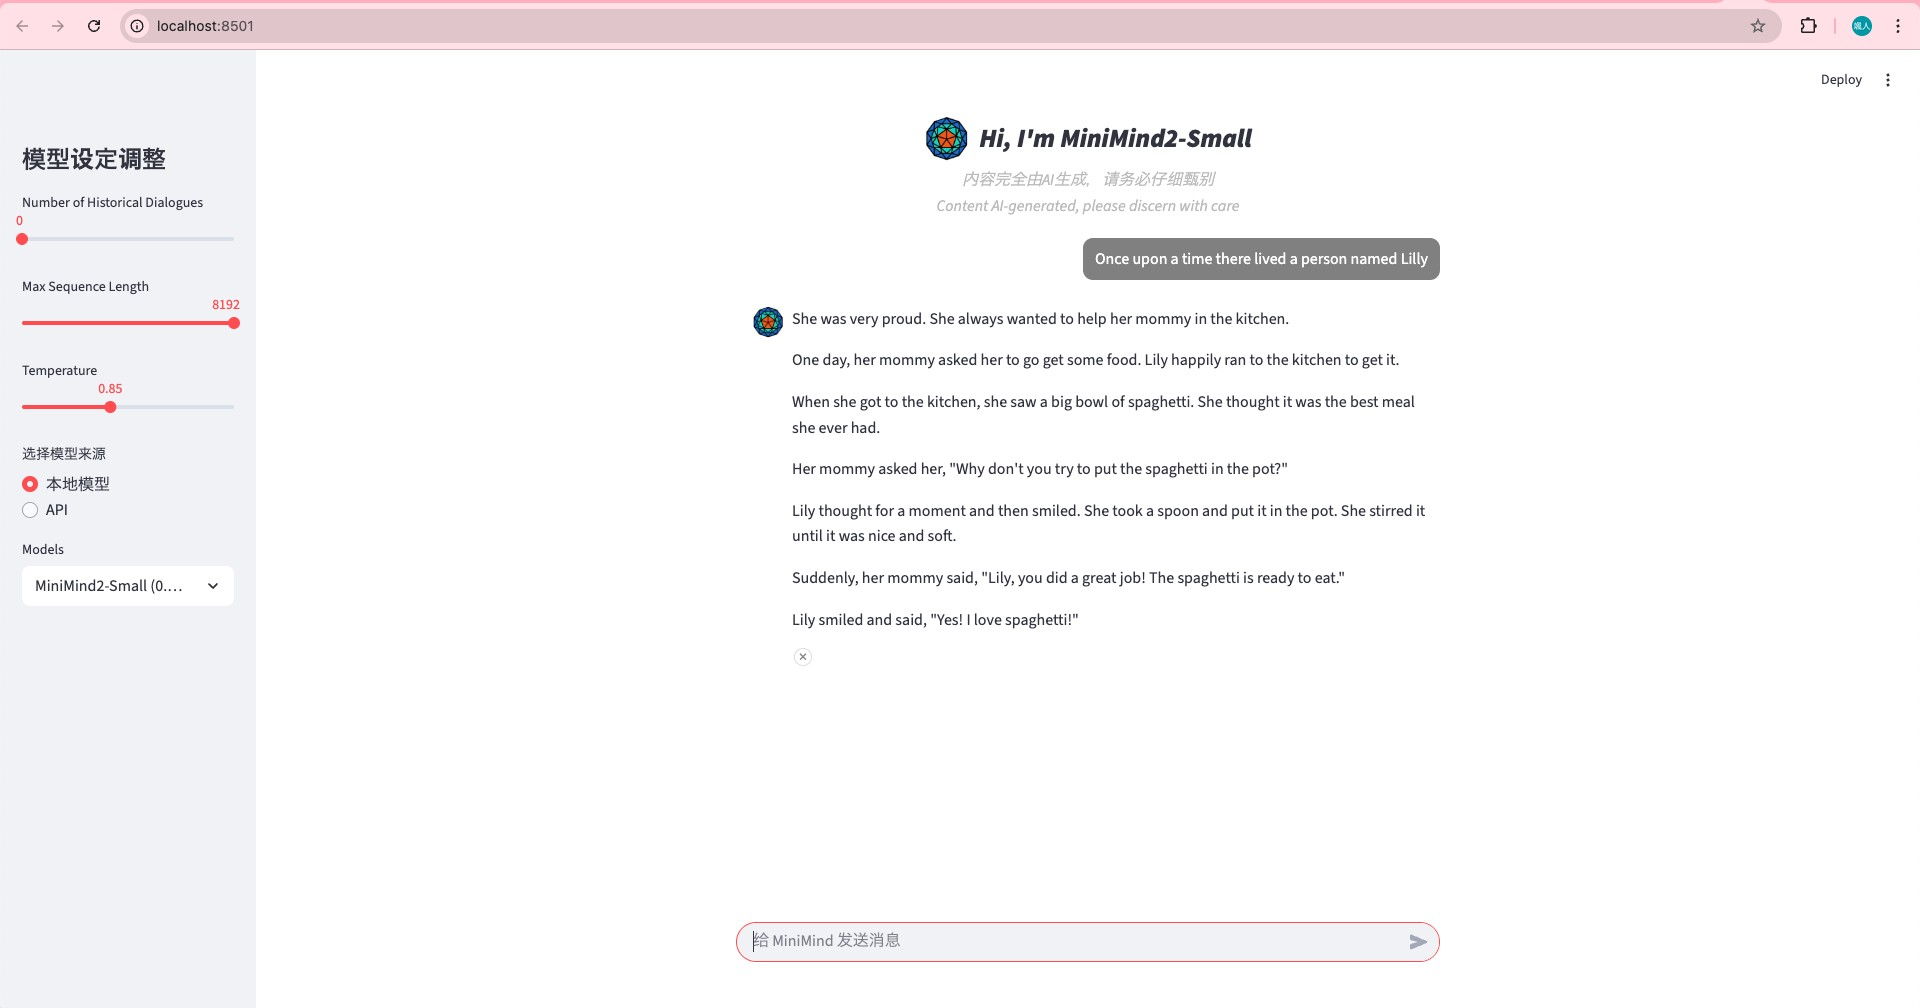

今までは、CPUを用いて訓練していました。

Google Colab では 無料の T4 GPU というGPUが提供されています。

この章から先は、基本的にこのT4 GPUを用いて訓練をしていきます。

なお、GPUは、CPUとは違い並列処理が得意でGPTの処理に非常に向いています。

...と口だけで言っても意味がないので、実際に計測していきましょう。

### **Section 1: `tokens_per_second`の練習**

今回のChapterがCPUの性能測定、次のChapterがGPUの性能測定です。

まずはランタイムをCPUに設定してください。[動画](https://youtu.be/XRmI-qRiFFw).<br>


念のため確認しましょう。

In [ ]:
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # 使用デバイス（GPUまたはCPU）
print(device_type)

cpu


**`Check Point`**  
<label><input type="checkbox">ランタイムがcpuに設定されていることを確認した<br></label>  

ここは EveryonesAI サーキット。さあ、CPUとGPUのレースが始まります。

まずはCPU選手の速度を計測しましょう。

すなわち、1秒間に何トークン処理できるかという、`tokens_per_second` を算出します。

tokens_per_second = 1stepでのトークン処理数(tokens) / 1step にかかった時間(秒) で計算されます。

In [ ]:
import time

このコードは、**現在のUNIX時間（エポック秒）** を取得しています。

`time.time()` は「1970年1月1日 00:00:00 UTC」からの経過秒数を返す関数です。

In [ ]:
start_time = time.time()
print("start_time\n", start_time)

start_time
 1761924060.4906757


約10秒だけ待ってから、再計測してみてください。10秒はだいたいの感覚で大丈夫です。

10, 9, 8, 7, 6, 5, 4, 3, 2, 1...さあ、コードセルを実行しよう！

In [ ]:
current_time = time.time()
print("current_time\n", current_time)

current_time
 1761924060.5082076


経過時間`elapsed_time`を算出してください。

In [ ]:
elapsed_time = current_time - start_time # TODO: THINK_BY_YOURSELF
print("elapsed_time\n", elapsed_time)

elapsed_time
 0.017531871795654297


例えば、1stepに1,000トークン処理できたとします。そして1stepに10秒かかったとます。

この時、`tokens_per_second` を計算してみましょう。

In [ ]:
tokens_per_step = 1_000
elapsed_time = 10
tokens_per_second = tokens_per_step / elapsed_time # TODO: THINK_BY_YOURSELF
print("tokens_per_second\n", tokens_per_second)

tokens_per_second
 100.0


ここで、以下のようなConfigの設定を考えます。




In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    batch_size = 16  # 一度に処理するデータ数（バッチサイズ）
    input_sequence_length = 512  # 入力データの長さ（系列長）
    device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # 使用デバイス（GPUまたはCPU）

In [ ]:
# 設定を確認してください
config = ModelConfig()

print("ModelConfigクラスの各設定:")
print(f"Batch size: {config.batch_size}")
print(f"Input sequence length: {config.input_sequence_length}")
print(f"Device in use: {config.device_type}")

ModelConfigクラスの各設定:
Batch size: 16
Input sequence length: 512
Device in use: cpu


1stepあたりに処理されるトークン数を算出しましょう。

In [ ]:
tokens_per_step = config.batch_size * config.input_sequence_length # TODO: THINK_BY_YOURSELF
print("tokens_per_step\n", tokens_per_step)

tokens_per_step
 8192


ここでさらに、100stepおきにevaluationが入るとします。

あるevaluationから、次のevaluationまでに、何トークンが処理されるでしょうか。

`tokens_per_evaluation_interval` を算出してください。

In [ ]:
config.evaluation_frequency = 100  # モデル性能評価の頻度

tokens_per_evaluation_interval = tokens_per_step * config.evaluation_frequency # TODO: THINK_BY_YOURSELF
print("tokens_per_evaluation_interval\n", tokens_per_evaluation_interval)

tokens_per_evaluation_interval
 819200


ここで、あるevaluationから、次のevaluationまでに、100秒経過していたとします。

`tokens_per_second` を計算してください。

In [ ]:
elapsed_time = 100

tokens_per_second = tokens_per_evaluation_interval / elapsed_time # TODO: THINK_BY_YOURSELF
print("tokens_per_second\n", tokens_per_second)

tokens_per_second
 8192.0


これで準備はできました。次のセクションに進みましょう。

**Section 1: `tokens_per_second`の練習** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: `Trainer`クラスの定義**

`tokens_per_second` を `Trainer`クラスに統合します。

その前に、前回の`Trainer`クラスを復習しましょう。

面倒だと思うかもしれません。私たちのカリキュラムの目標は、大学1年生が1年のサークル活動でChatGPTを作れる世界です。

私たちのカリキュラムの原則は、先人たちのカリキュラムにより細かい段差を刻み、誰もが登れる階段を作ることです。

重複が発生する時もあります。それは階段の踊り場のようなものだと思ってください。

何より、深く理解している方なら重複があっても1分もかかりません。

🔘 **Options**: 不要な追加オプションがあるかもしれません。

`self.model`　`self.optimizer`　`self.data_loader`　`self.config`　`split_data`　`get_batch`　`'train'`、`'val'`　`input_batch`　`target_batch`　`logits`　`self.config.total_training_steps`　`self.config.evaluation_loops`  
`loss`　`backward()`　`self.train_step()`　`self.evaluate()`

In [ ]:
class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # configで指定された回数だけtrain_stepを実行。
        for step in range(self.config.total_training_steps):

            # 100ステップごと、または最終ステップのみ評価を行う。
            if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
                eval_loss = self.evaluate()
                print(f"Step {step}: Train Loss {eval_loss['train']:.4f}, Validation Loss {eval_loss['val']:.4f}")

            # トレーニングの1ステップ（毎回行うメイン処理）
            train_loss = self.train_step()

In [ ]:
"""
class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

    def train_step(self):
        # 訓練用のバッチを取得する。
        input_batch, target_batch = ___________._______(_____)
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = _______(_________, __________)
        _____.__________  # 逆伝播（誤差逆伝播）
        self.optimizer.step()  # パラメータを更新する

        return loss.item() # 損失の値を返します

    def evaluate(self):
        self.model.eval()  # 評価モードに設定する
        losses = {"train": [], "val": []} # 訓練データおよび検証データで損失を計算する
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 訓練モードに戻る

        # 各分割（train、val）の平均損失を計算する
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # configで指定された回数だけtrain_stepを実行します。
        for step in range(_________________________):

            # 100イテレーションごと、または最終ステップでのみ評価する。
            if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
                eval_loss = self.evaluate()
                print(f"Step {step}: Train Loss {eval_loss['train']:.4f}, Validation Loss {eval_loss['val']:.4f}")

            # トレーニングの1ステップ（毎回行う主要な処理）
            train_loss = _____________
            # 戻り値なし
"""

'\nclass Trainer:\n    def __init__(self, model, optimizer, data_loader, config):\n        self.model = model\n        self.optimizer = optimizer\n        self.data_loader = data_loader\n        self.config = config\n\n    def train_step(self):\n        # 訓練用のバッチを取得する。\n        input_batch, target_batch = ___________._______(_____)\n        self.optimizer.zero_grad()\n\n        # モデルの順伝播と損失計算\n        logits, loss = _______(_________, __________)\n        _____.__________  # 逆伝播（誤差逆伝播）\n        self.optimizer.step()  # パラメータを更新する\n\n        return loss.item() # 損失の値を返します\n\n    def evaluate(self):\n        self.model.eval()  # 評価モードに設定する\n        losses = {"train": [], "val": []} # 訓練データおよび検証データで損失を計算する\n        with torch.no_grad():\n            for split in [\'train\', \'val\']:\n                for _ in range(self.config.evaluation_loops):\n                    input_batch, target_batch = self.data_loader.get_batch(split)\n                    _, loss = self.model(input_batch, target_

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # configで指定された回数だけtrain_stepを実行。
        for step in range(self.config.total_training_steps):

            # 100ステップごと、または最終ステップのみ評価を行う。
            if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
                eval_loss = self.evaluate()
                print(f"Step {step}: Train Loss {eval_loss['train']:.4f}, Validation Loss {eval_loss['val']:.4f}")

            # トレーニングの1ステップ（毎回行うメイン処理）
            train_loss = self.train_step()
```

お待たせいたしました。`train` メソッドに、`tokens_per_second`を統合することで、新しい`new_train`関数を作成します。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`time.time()`　`None`　`torch`　`time`　`self.config.batch_size`　`self.config.input_sequence_length`　`if`　`last_eval_end_time`　`tokens_per_evaluation_interval`　`evaluation_interval`　`self.config.evaluation_frequency`

In [ ]:
############ NEW ############
import time
############ NEW ############
def new_train(self):
    # configで指定された回数だけtrain_stepを実行する。
    for step in range(self.config.total_training_steps):

        # 100回ごと、または最終ステップのみ評価する。
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
            ########## NEW ##########
            # step==0 は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。
            if step == 0 or step == self.config.total_training_steps - 1:
              tokens_per_second = None
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval
            ########## NEW ##########

            eval_loss = self.evaluate()
            print(f"Step {step}: Train Loss {eval_loss['train']:.4f}, Validation Loss {eval_loss['val']:.4f}")

            ########## NEW ##########
            print(f"Tokens per second {tokens_per_second}")
            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()
            ########## NEW ##########

        # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()

In [ ]:
"""
############ NEW ############
import ____
############ NEW ############
def new_train(self):
    # configで指定された回数だけtrain_stepを実行する。
    for step in range(self.config.total_training_steps):

        # 100回ごと、または最終ステップのみ評価する。
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
            ########## NEW ##########
            # step==0 は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。
            if step == 0 or step == self.config.total_training_steps - 1:
              tokens_per_second = ____
            else:
              current_eval_start_time = ________
              evaluation_interval = current_eval_start_time - _______________
              tokens_per_evaluation_interval = ______________ * _______________________ * _________________________
              tokens_per_second = _______________ / ____________
            ########## NEW ##########

            eval_loss = self.evaluate()
            print(f"Step {step}: Train Loss {eval_loss['train']:.4f}, Validation Loss {eval_loss['val']:.4f}")

            ########## NEW ##########
            print(f"Tokens per second {tokens_per_second}")
            # この評価が終わった時間を記録することで、次の評価開始時に
            last_eval_end_time = ___________
            ########## NEW ##########

        # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()
"""

'\n############ NEW ############\nimport ____\n############ NEW ############\ndef new_train(self):\n    # configで指定された回数だけtrain_stepを実行する。\n    for step in range(self.config.total_training_steps):\n\n        # 100回ごと、または最終ステップのみ評価する。\n        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:\n            ########## NEW ##########\n            # step==0 は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。\n            if step == 0 or step == self.config.total_training_steps - 1:\n              tokens_per_second = ____\n            else:\n              current_eval_start_time = ________\n              evaluation_interval = current_eval_start_time - _______________\n              tokens_per_evaluation_interval = ______________ * _______________________ * _________________________\n              tokens_per_second = _______________ / ____________\n            ########## NEW ##########\n\n            eval_loss = self.evaluate()\n            p

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
############ NEW ############
import time
############ NEW ############
def new_train(self):
    # configで指定された回数だけtrain_stepを実行する。
    for step in range(self.config.total_training_steps):
      
        # 100回ごと、または最終ステップのみ評価する。
        if step % self.config.evaluation_frequency == 0 or step == self.config.total_training_steps - 1:
            ########## NEW ##########
            # step==0 は last_eval_end_time 未定義のため除外。最終ステップは途中計測になる可能性があるため除外。
            if step == 0 or step == self.config.total_training_steps - 1:
              tokens_per_second = None
            else:
              current_eval_start_time = time.time()
              evaluation_interval = current_eval_start_time - last_eval_end_time
              tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.tokens_per_evaluation_interval
              tokens_per_second = tokens_per_evaluation_interval / evaluation_interval
            ########## NEW ##########

            eval_loss = self.evaluate()
            print(f"Step {step}: Train Loss {eval_loss['train']:.4f}, Validation Loss {eval_loss['val']:.4f}")

            ########## NEW ##########
            print(f"Tokens per second {tokens_per_second}")
            # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
            last_eval_end_time = time.time()
            ########## NEW ##########

        # 1回の学習ステップ（毎回行う主な処理）
        train_loss = self.train_step()
```

🔧 クラスメソッド差し替えの公式

```python
def 新しい関数(self, ...):
    ...

既存クラス.メソッド名 = 新しい関数
```

* **メソッド名はそのまま**（`train()` で呼べる）
* **中身だけ置き換わる**（`new_train` の処理が実行される）
<br>

In [ ]:
Trainer.train = new_train

**Section 2: `Trainer`クラスの定義** <label><input type="checkbox"> Mark as Done</label>

### **Section 3: `tokens_per_second`の測定**

`Dataloader`クラスとモデルクラスを定義します。前回と完全に同じです。

In [ ]:
class DataLoader:
    def __init__(self, text, config):
        self.config = config  # 設定オブジェクト
        chars = sorted(list(set(text)))  # ユニークな文字をソートする
        self.ctoi = {char: index for index, char in enumerate(chars)}
        self.itoc = {index: char for index, char in enumerate(chars)}
        self.vocab_size = len(chars)

        # エンコードしてテンソルに変換する。
        # `__init__`外のメソッドや引数を呼ぶには`self.`が必要です。
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        # 訓練用と検証用に分割する。
        # 引数が指定されなくてもself.dataが使われます。
        self.train_data, self.val_data = self.split_data()

    def encode(self, text):
        # 文字列をインデックス列に変換します。self.で他のメソッドや引数を呼び出します。
        return [self.ctoi[c] for c in text]

    def decode(self, indices):
        return ''.join([self.itoc[i] for i in indices])

    def split_data(self):
        split_index = int(0.9 * len(self.data))  # データの90%を訓練用に分割するポイント。
        return self.data[:split_index], self.data[split_index:]

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        start_indices = torch.randint(len(data) - self.config.input_sequence_length, (self.config.batch_size,)) # 抽出開始インデックスを生成する

        input_sequences = torch.stack([
            data[start_index:start_index + self.config.input_sequence_length]
            for start_index in start_indices
        ])
        target_sequences = torch.stack([
            data[start_index + 1:start_index + self.config.input_sequence_length + 1]
            for start_index in start_indices
        ])
        return input_sequences.to(self.config.device_type), target_sequences.to(self.config.device_type)


In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings

class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(vocab_size, config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

トレーニングを開始して、`tokens_per_second`を測定しましょう。

最初は、以下の設定で行います。



In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    ########## NEW ##########
    batch_size = 1  # まずはバッチサイズを1に設定する。並列計算はなし。
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    total_training_steps = 150  # あくまでtokens per secondの計測なので、最大ステップ回数は150程度に設定する。
    device_type = 'cpu'  # 使用デバイスはCPUに固定する
    ########## NEW ##########
    evaluation_frequency = 100  # モデル性能評価の頻度
    learning_rate = 0.001  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 64  # 埋め込み層サイズ（特徴ベクトルの次元数）
    hidden_dim = 256
    num_attention_heads = 4  # ノート機構ヘッド番号
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

In [ ]:
# データを読み込む
with open("input.txt", 'r', encoding = 'utf-8') as f:
    text_data = f.read()
data_loader = DataLoader(text_data, config)

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)  # 使用するデバイスを指定してください
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

0.240449 M parameters


In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
Step 0: Train Loss 4.3347, Validation Loss 4.3314
Tokens per second None
Step 100: Train Loss 2.8271, Validation Loss 2.7818
Tokens per second 2336.83370800399
Step 149: Train Loss 2.6481, Validation Loss 2.7399
Tokens per second None


**`Check Point`**  
<label><input type="checkbox">`tokens_per_second`を確認した<br></label>  

バッチサイズを1から16に増やしてみて、同様の計算を行います。

In [ ]:
config.batch_size = 16

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)  # 使用するデバイスを指定してください
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
Step 0: Train Loss 4.3251, Validation Loss 4.3251
Tokens per second None


KeyboardInterrupt: 

CPUは並列計算できないため、処理時間はほぼ**バッチサイズに比例**します。  
バッチサイズ1で30秒なら、16では約8分ほどです。待っている間に、

右上の「RAM・ディスク」横の🔽をクリックし、**「リソースを表示」** を開いてください。

[Watch the video!](https://youtu.be/pKL5bZFl2EU)
- 10秒（音声なし）

「システムRAM」で現在のメモリ使用率を確認できます。

| 用語 | 説明 |
|------|------|
| **RAM（メモリ）** | 今まさに使っている作業スペース |
| **ディスク** | データを長期保存する場所（例：`input.txt`） |

バッチサイズを増やすと、一度に保持するデータ（テンソル）が増えるため、  
メモリ使用量も増えます。

そろそろ8分くらい経ったかも。`tokens_per_second`を確認してみましょう。

**`Check Point`**  
<label><input type="checkbox">CPUについて、`tokens_per_second`がバッチサイズ1と16でほぼ等しいことを確認した<br></label>  

**Section 3: `tokens_per_second`の測定** <label><input type="checkbox"> Mark as Done</label>

### **Section 4: セッションをクラッシュさせる**

メモリを使い切ることで、セッションをクラッシュさせたいと思います。

バッチサイズを極端に、例えば64倍に増やすと、どうなるでしょう？

In [ ]:
config.batch_size = 1024

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)  # 使用するデバイスを指定してください
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

実はクラッシュしません。1分くらい実行したところでストップしてください。

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

それぞれのサンプルは独立しているので、小分けにできます。

バッチサイズが極端に大きいと、小分けにして処理してくれることがあり、意外と平気です。

逆に、小分けにできないものがありますよね。

そうです、入力シーケンス長です。

attentionの計算があるので、前半だけとか、後半だけとかに分割できません。

これを元の512から16倍、つまり8192に増やしてみましょう。

In [ ]:
config.batch_size = 16
config.input_sequence_length = 8192

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)  # 使用するデバイスを指定してください
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===


KeyboardInterrupt: 

メモリを使い果たすと、セッションがクラッシュし、実行中の変数や結果はすべて消えてリセットされます。

特に Attention の計算（クエリ行列 × キー行列の内積）は、**シーケンス長の2乗**に比例して増えるため、急激にメモリを消費します。

---

**「学習できるシーケンス長には限界がある」**

---

これは非常に重要なテーマです。  
長い文章を学習させるために、人々はいくつかの工夫を考えました：

| # | アプローチ | 概要 |
|---|-------------|------|
| 1 | 大容量のRAMを使う (HBM) | メモリ単体を大容量化 |
| 2 | メモリをたくさん置く| 全体で容量を増やす |
| 3 | 複数文字をまとめて1トークンにする（tiktoken など） | 実質的にシーケンス長を短縮 |
| 4 | Attention計算を効率化（FlashAttention など） | メモリ使用を最小化しつつ高速化 |
| 5 | 短文学習だけど長文推論ができる（RoPE） | 長文推論を可能にする「裏ワザ」 |

---

3, 4, 5 については後の章で詳しく説明します。

まずは、1を見ていきましょう。

CPUやGPUはあくまで演算装置です。今回はCPUでしたが、GPUにもメモリはついています。

みなさんお馴染み、GPU設計・販売大手のNVIDIAは、AI学習・推論向けの高速・大容量メモリを韓国のSK hynixから調達しています。

NVIDIAの株価急騰は有名ですが、SK hynixも急騰しています。

Google で 「SK hynix stock price」で検索して、表示期間をMaxに設定してみてください。

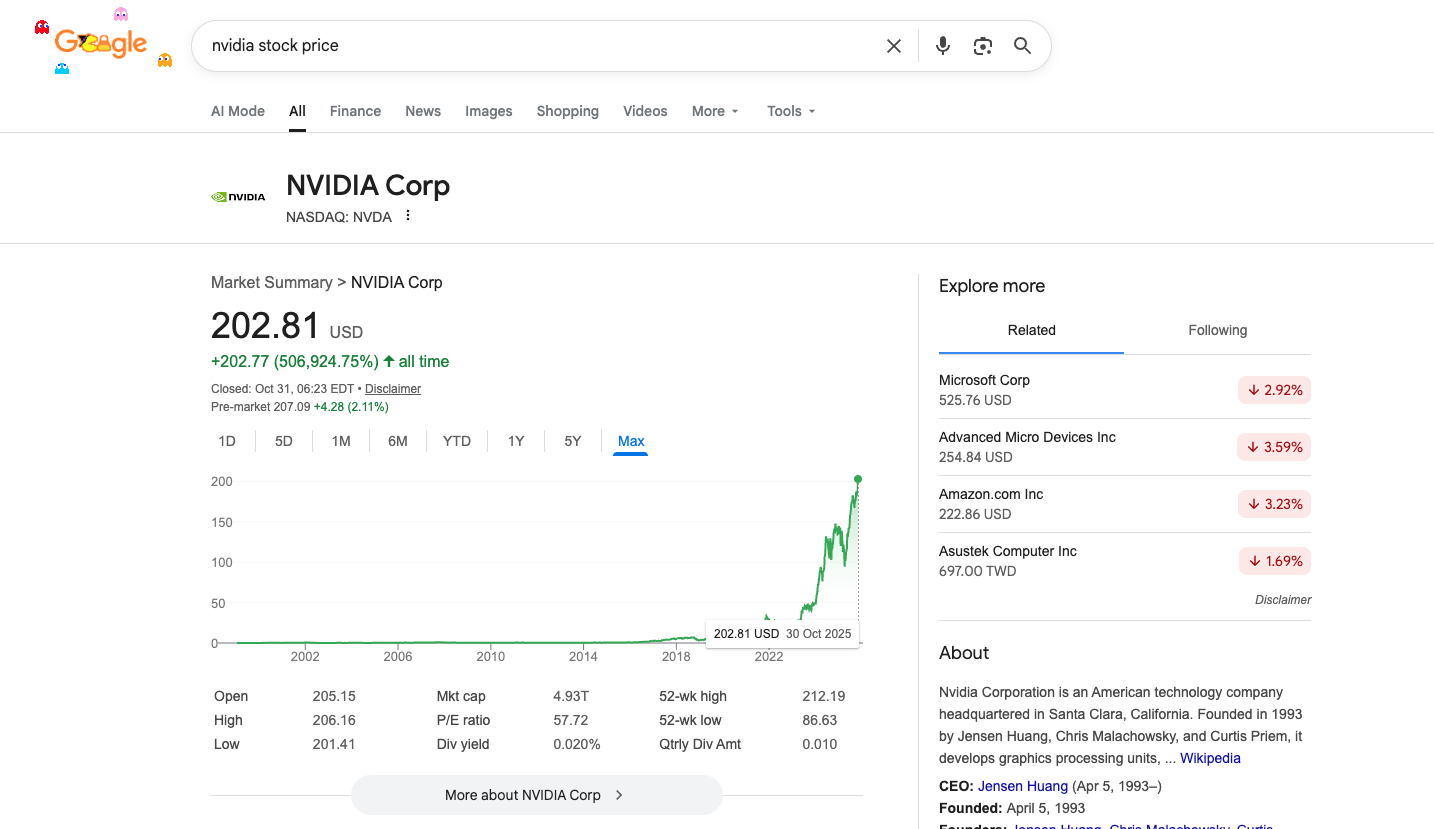

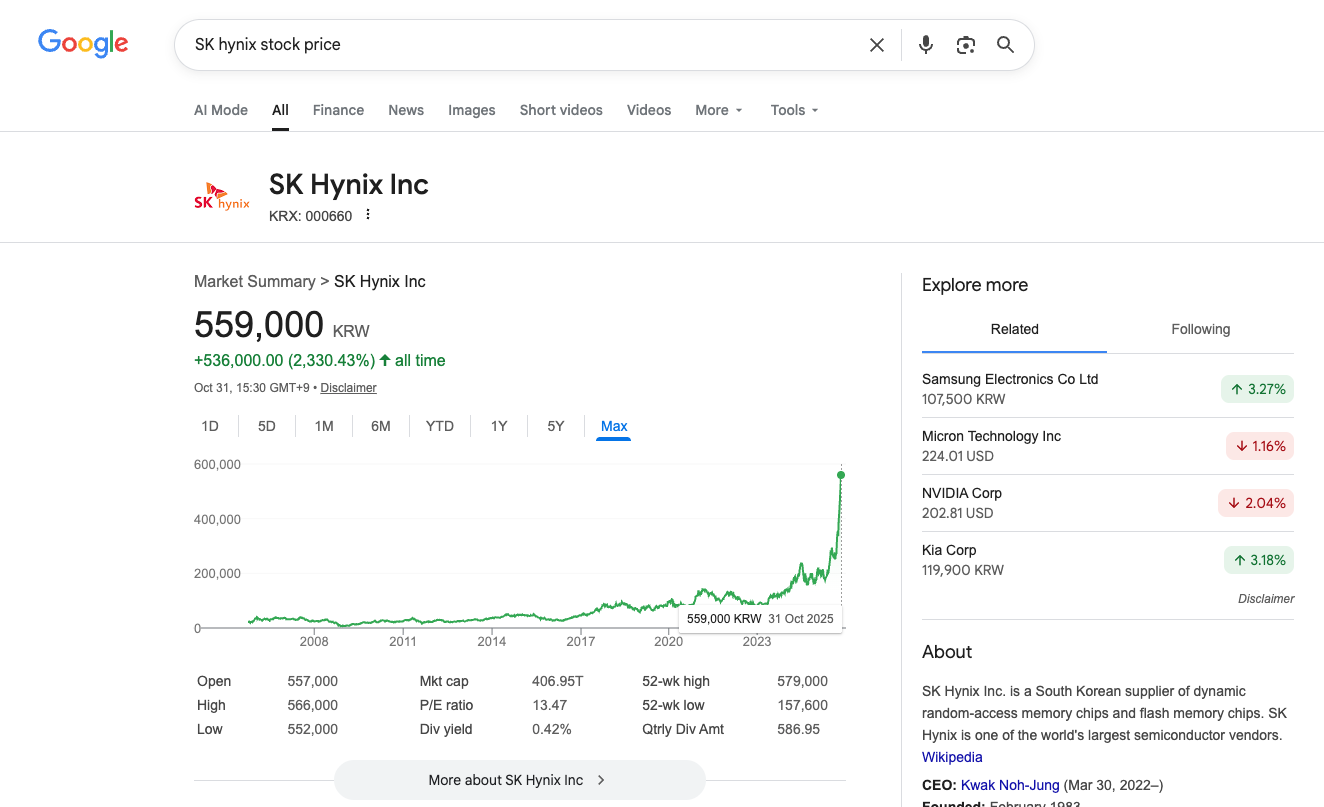

なお、このAI学習/推論向けの高性能メモリをめぐっては、SK hynix と Samsung の激しい技術競争があります。これも面白いので、興味があったら調べてみてください。

※注意：株式の購入を勧めるものではありません。投資は自己責任でお願いします。

もう1つの方法は、メモリをたくさん置くことで、全体の容量を増やす方法です。

これは台湾の半導体製造の巨人TSMCの独壇場です。

以下の図を見ると、端っこについてるメモリ(HBM)の数が増えていることがわかります。

なお、容量だけではなく、データ転送の高速化というのも大きなテーマです。詳しく知りたい方は「CoWoS」というキーワードで、ご自身で調べてみてください。

[図の出典はこちらの22ページ](https://hc33.hotchips.org/assets/program/tutorials/2021%20HotChips%20TSMC%20Packaging%20Technologies%20for%20Chiplets%20and%203D_0819%20publish_public.pdf)


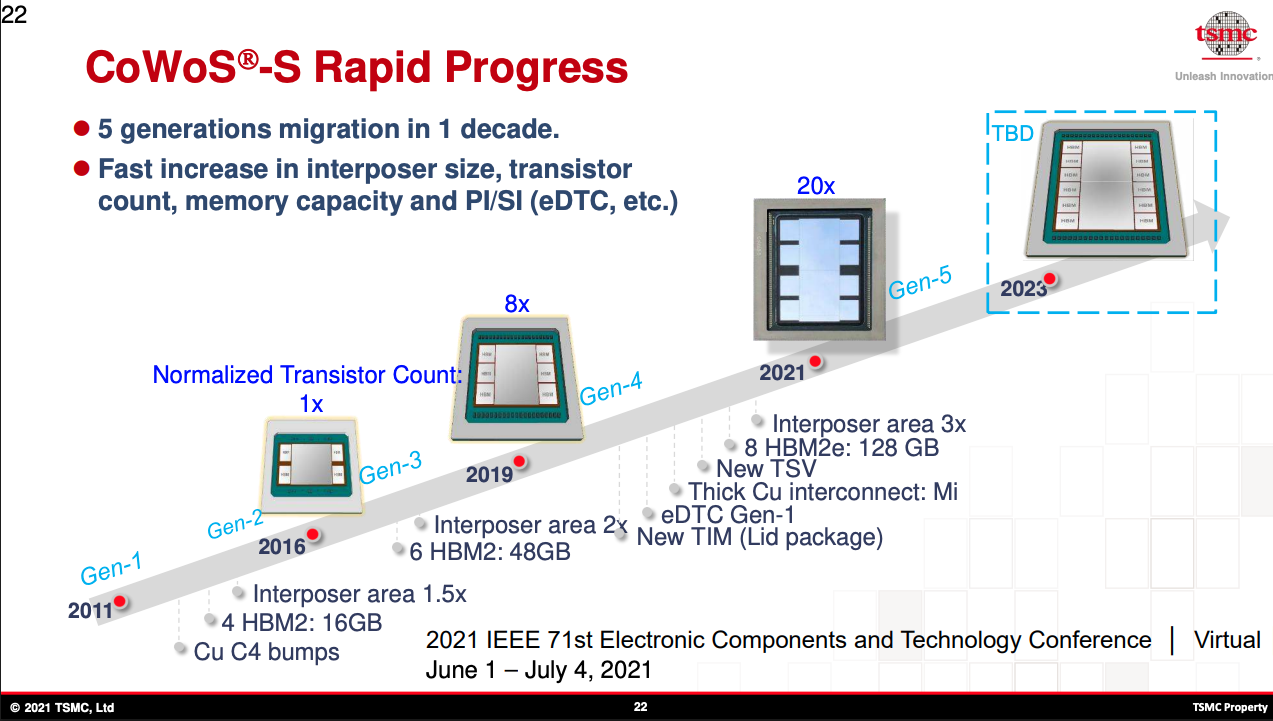

なお、2027年からは更にとんでもない数に増える予定です。

これも「SoW」というキーワードで興味があれば調べてみてください。



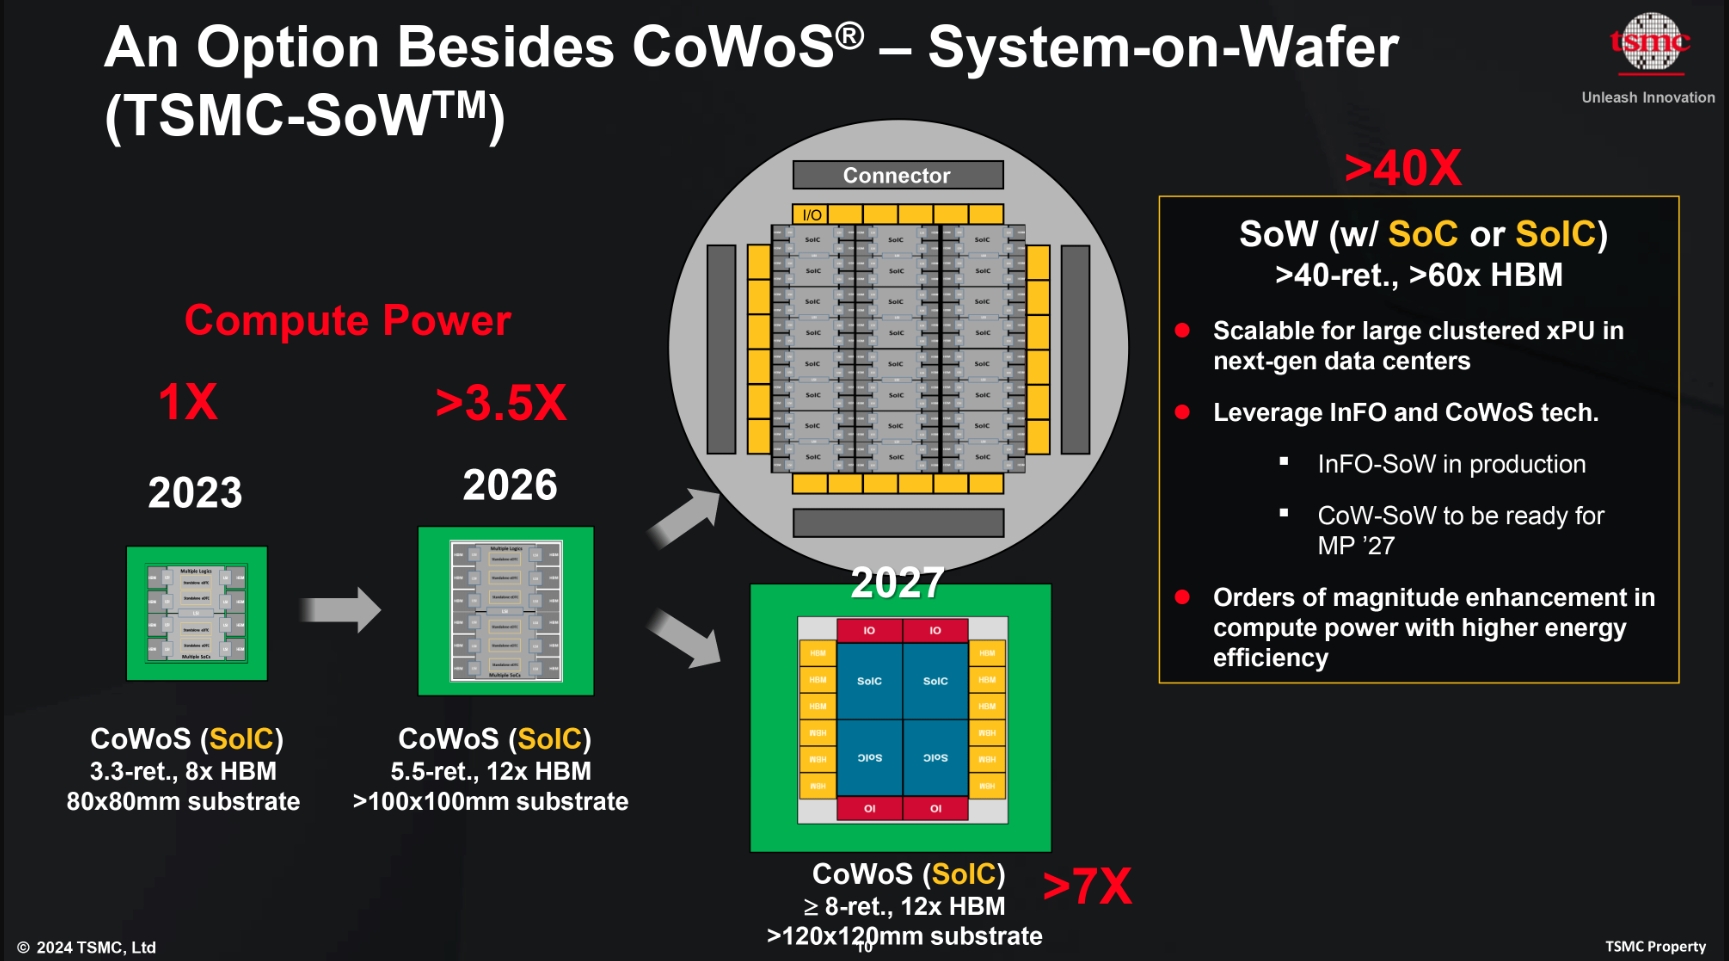

図の出典はこちら

> Shi­l­ov, A. (2024, April 26). *TSMC to go 3D with wafer-sized processors — CoW-SoW: System-on-Wafer technology allows 3D stacking for the world’s largest chips*. Tom’s Hardware. [https://www.tomshardware.com/tech-industry/tsmc-to-go-3d-with-wafer-sized-processors-cow-sow-system-on-wafer-technology-allows-3d-stacking-for-the-worlds-largest-chips](https://www.tomshardware.com/tech-industry/tsmc-to-go-3d-with-wafer-sized-processors-cow-sow-system-on-wafer-technology-allows-3d-stacking-for-the-worlds-largest-chips)

ハードウェア要件もなんとなく把握していると、アルゴリズム分野のテーマも分かります。

深入りすると帰れなくなるので、とりあえずここでstopしましょう。

今後も大きな変化があるかもしれません。毎年4月春にTSMCが「North American symposium」というのを開いているので、関連記事は毎年チェックしておいてください。

Chapter 14では、GPUで tokens per second を測定します。

手順は同じです。すぐ終わります。Chapter 14に進みましょう。

**Section 4: セッションをクラッシュさせる** <label><input type="checkbox"> Mark as Done</label>

**`Chapter 13: Tokens per second(CPU)`** <label><input type="checkbox"> Mark as Done</label>